In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 9-1
- A square $Q$ has the following equalities, demonstrate this in code by computing $Q$ from a random matrix and show for all 4 expressions the result is the identity matrix
$$
Q^T Q = Q Q^T = Q^{-1} Q = Q Q^{-1} = I
$$

In [3]:
A = np.random.default_rng().random((3, 3))
Q, _ = np.linalg.qr(A)
Q

array([[-0.53068632,  0.74381509,  0.40633871],
       [-0.57547509,  0.03575766, -0.81703721],
       [-0.62225433, -0.66742828,  0.40907095]])

In [4]:
Q.T @ Q

array([[ 1.00000000e+00,  1.27944418e-16,  3.61138357e-17],
       [ 1.27944418e-16,  1.00000000e+00, -8.78929436e-17],
       [ 3.61138357e-17, -8.78929436e-17,  1.00000000e+00]])

In [5]:
Q @ Q.T

array([[ 1.00000000e+00, -5.55111512e-17, -1.38777878e-16],
       [-5.55111512e-17,  1.00000000e+00,  0.00000000e+00],
       [-1.38777878e-16,  0.00000000e+00,  1.00000000e+00]])

In [6]:
np.linalg.inv(Q) @ Q

array([[ 1.00000000e+00,  5.40986613e-17, -5.47181626e-17],
       [ 3.34915837e-18,  1.00000000e+00,  1.30342068e-17],
       [ 4.96867925e-17,  9.72287832e-17,  1.00000000e+00]])

In [7]:
Q @ np.linalg.inv(Q)

array([[ 1.00000000e+00,  1.58759739e-17,  3.44371605e-17],
       [ 3.61889239e-17,  1.00000000e+00,  1.93829244e-16],
       [ 6.94546678e-17, -7.90241138e-18,  1.00000000e+00]])

# Exercise 9-3
- See what happens when you attempt QR decomposition to a matrix that is almost-but-not-quite orthogonal
- Create an orthogonal matrix $U$ from the QR decomposition of a 6x6 matrix
- Compute the QR decomposition of $U$ and confirm that $R = I$ and WHY
- Modify the norms of each column of $U$ to be 10-15 i.e. vector from 10-15 @ U
- Run modulated $U$ through QR decomposition and confirm that it's $R$ is the diagonal elements equaling 10-15
- What is the $Q^T Q$ for this matrix?
- Break the orthogonality of $U$ by setting element $u_{1,4} = 0$. What happens to $R$ and why?

In [10]:
U, _ = np.linalg.qr(np.random.default_rng().random((6, 6)))
U

array([[-0.07918398, -0.26091136,  0.73684914,  0.22533708, -0.4438026 ,
        -0.36738393],
       [-0.33723158, -0.80610302, -0.22420976,  0.26835078,  0.01877027,
         0.33739933],
       [-0.51346968, -0.07748051, -0.38034736, -0.32769338, -0.09345833,
        -0.6852475 ],
       [-0.3942302 ,  0.02559966,  0.4458975 , -0.05340132,  0.80047438,
        -0.03862239],
       [-0.54933743,  0.25226231,  0.18819836, -0.41333064, -0.38550398,
         0.52888369],
       [-0.39895436,  0.46024813, -0.16696111,  0.77209727, -0.06767505,
        -0.02041954]])

In [50]:
_, R = np.linalg.qr(U)
# R will be an identity matrix because U is already orthogonal and thus to QR decompose an already orthogonal matrix we would just need to split out the Identity matrix
R

array([[ 1.00000000e+00, -1.18431017e-17,  3.19098286e-17,
         5.77880624e-17, -1.02047154e-16, -1.05087994e-16],
       [ 0.00000000e+00,  1.00000000e+00, -2.23179611e-16,
        -8.40656281e-17,  4.06470427e-17,  9.80356307e-17],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        -3.63128351e-17,  6.20062744e-17, -1.89868570e-16],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  3.85545192e-16,  8.13811393e-17],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00, -3.43284912e-16],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])

In [31]:
v = np.arange(10, 16)
v

array([10, 11, 12, 13, 14, 15])

In [32]:
np.linalg.norm(U[:,0])

np.float64(0.9999999999999999)

In [46]:
U_mod = v * U
U_mod

array([[ -0.79183983,  -2.87002498,   8.84218967,   2.92938204,
         -6.21323647,  -5.51075896],
       [ -3.37231576,  -8.8671332 ,  -2.69051717,   3.48856016,
          0.2627838 ,   5.06098988],
       [ -5.13469683,  -0.85228564,  -4.56416827,  -4.26001393,
         -1.30841664, -10.27871247],
       [ -3.94230195,   0.28159624,   5.35077004,  -0.69421718,
         11.20664135,  -0.5793359 ],
       [ -5.49337432,   2.77488537,   2.25838027,  -5.37329828,
         -5.39705567,   7.93325542],
       [ -3.98954365,   5.06272943,  -2.00353331,  10.03726448,
         -0.94745076,  -0.30629311]])

In [51]:
U_mod_Q, R_mod = np.linalg.qr(U_mod)
R_mod

array([[ 1.00000000e+01, -2.41296421e-16,  2.26476904e-15,
         8.24338339e-16, -2.72023499e-15, -1.46529761e-15],
       [ 0.00000000e+00,  1.10000000e+01, -4.14872507e-15,
         1.12911552e-15,  1.21625520e-15,  2.42221766e-15],
       [ 0.00000000e+00,  0.00000000e+00,  1.20000000e+01,
        -9.93273952e-16, -9.42907311e-17,  1.10821429e-15],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.30000000e+01,  5.99380663e-15,  1.16005627e-16],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.40000000e+01, -4.37820625e-15],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.50000000e+01]])

In [52]:
U_mod_Q.T @ U_mod_Q

array([[ 1.00000000e+00,  7.17391635e-17, -1.73905471e-16,
         4.96379212e-17,  1.04754483e-16,  2.27054516e-16],
       [ 7.17391635e-17,  1.00000000e+00, -3.36766722e-17,
         1.09058190e-16,  6.26346426e-17,  3.07945417e-17],
       [-1.73905471e-16, -3.36766722e-17,  1.00000000e+00,
         8.96965099e-18, -3.71099244e-17, -1.30434521e-16],
       [ 4.96379212e-17,  1.09058190e-16,  8.96965099e-18,
         1.00000000e+00,  1.36059080e-16,  4.97584811e-18],
       [ 1.04754483e-16,  6.26346426e-17, -3.71099244e-17,
         1.36059080e-16,  1.00000000e+00,  7.49286923e-18],
       [ 2.27054516e-16,  3.07945417e-17, -1.30434521e-16,
         4.97584811e-18,  7.49286923e-18,  1.00000000e+00]])

In [53]:
U[0,3] = 0
_, Broken_R = np.linalg.qr(U)
# It is close to the identity matrix but not quite because by modifying U we made it linear dependent
Broken_R

array([[ 1.00000000e+00, -1.18431017e-17,  3.19098286e-17,
         1.78430875e-02, -1.02047154e-16, -1.05087994e-16],
       [ 0.00000000e+00,  1.00000000e+00, -2.23179611e-16,
         5.87930046e-02,  4.06470427e-17,  9.80356307e-17],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        -1.66039434e-01,  6.20062744e-17, -1.89868570e-16],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         9.58060078e-01,  1.04382998e-01,  8.64092181e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  9.94537174e-01, -9.06919668e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  9.96218448e-01]])

# Exercise 9-4
- copy code from exercise 8-2 into a function that takes a matrix as input an outputs the inverse
- Create a 5x5 matrix, use the function to find the inverse as well as the QR decomposition method
- compute the inverse-estimation error as the Euclidean distance from the matrix times its inverse to the true identity matrix from `np.eye`
- Make a bar plot showing the two methods and error

In [57]:
def old_school_inv(M: np.ndarray) -> np.ndarray:
    row_count = M.shape[0]
    col_count = M.shape[1]

    minors_matrix = np.zeros((row_count, col_count))

    for row_idx in range(row_count):
        for col_idx in range(col_count):
            row_mask = np.arange(M.shape[0]) != row_idx
            col_mask = np.arange(M.shape[1]) != col_idx
            sum_matrix = M[row_mask][:, col_mask]
            minors_matrix[row_idx][col_idx] = np.linalg.det(sum_matrix)

    grid_matrix = np.zeros((row_count, col_count))
    for row_idx in range(row_count):
        for col_idx in range(col_count):
            grid_matrix[row_idx][col_idx] = (-1)**(row_idx +col_idx + 2)

    cofactors_matrix = minors_matrix * grid_matrix

    adjunct_matrix = cofactors_matrix.T * np.linalg.det(M)**(-1)
    return adjunct_matrix

In [69]:
five_by_five = np.random.default_rng().random((5, 5))
five_by_five

array([[0.65985698, 0.91841217, 0.2847408 , 0.90339846, 0.36588357],
       [0.57622244, 0.01984863, 0.71724089, 0.59921102, 0.11085509],
       [0.03110809, 0.45233859, 0.84957765, 0.15927551, 0.73929429],
       [0.39998831, 0.58316202, 0.92165066, 0.87319849, 0.03758971],
       [0.46009875, 0.31746389, 0.88864466, 0.28437219, 0.73484177]])

In [70]:
Q, R = np.linalg.qr(five_by_five)
R_inv = old_school_inv(R)
qr_inv = R_inv @ Q.T
qr_inv

array([[-0.49284029, -2.99431642, -4.87786136,  1.65679941,  5.51976496],
       [-0.37575325, -4.58234108, -3.29930657,  2.81493012,  4.05366707],
       [-1.22383608, -1.571079  , -1.41288816,  1.89501131,  2.17087666],
       [ 1.7130006 ,  5.94143041,  5.75867697, -3.35403748, -7.37121451],
       [ 1.28799013,  3.45511447,  3.9595688 , -3.24712991, -3.61914565]])

In [71]:
old_inv = old_school_inv(five_by_five)
old_inv

array([[-0.49284029, -2.99431642, -4.87786136,  1.65679941,  5.51976496],
       [-0.37575325, -4.58234108, -3.29930657,  2.81493012,  4.05366707],
       [-1.22383608, -1.571079  , -1.41288816,  1.89501131,  2.17087666],
       [ 1.7130006 ,  5.94143041,  5.75867697, -3.35403748, -7.37121451],
       [ 1.28799013,  3.45511447,  3.9595688 , -3.24712991, -3.61914565]])

In [72]:
qr_err, old_err = np.linalg.norm(five_by_five @ qr_inv - np.eye(5,5)), np.linalg.norm(five_by_five @ old_inv - np.eye(5,5))
qr_err, old_err

(np.float64(5.4821581892917325e-15), np.float64(5.298238003569152e-15))

<BarContainer object of 2 artists>

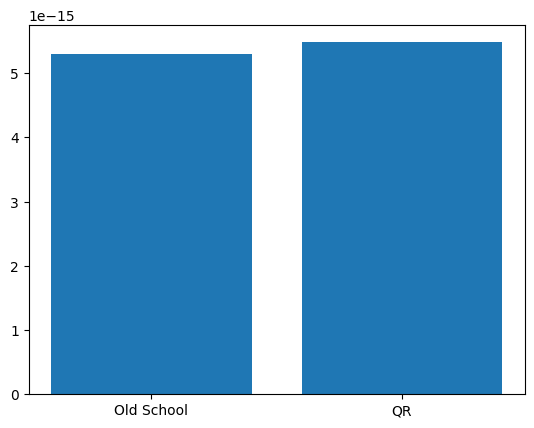

In [73]:
plt.bar(["Old School", "QR"], [old_err, qr_err])

In [123]:
iterations = 100
matrix_sizes = [5, 30, 100]
results = np.zeros((2*len(matrix_sizes), iterations))
for m_idx, matrix_size in enumerate(matrix_sizes):
    for i in range(iterations):
        M = np.random.default_rng().random((matrix_size, matrix_size))

        old_inv = old_school_inv(M)

        Q, R = np.linalg.qr(M)
        R_inv = np.linalg.inv(R)
        qr_inv = R_inv @ Q.T

        results[m_idx*2, i] = np.linalg.norm(M @ old_inv - np.eye(matrix_size,matrix_size))
        results[m_idx*2+1, i] = np.linalg.norm(M @ qr_inv - np.eye(matrix_size,matrix_size))


In [124]:
results

array([[2.90470464e-15, 1.59217669e-15, 1.22292283e-14, 1.76803686e-15,
        4.83203656e-15, 5.80599095e-16, 7.14601150e-16, 1.69662926e-15,
        8.03797716e-15, 1.10943108e-14, 3.29805225e-15, 1.03254421e-15,
        7.92270357e-14, 2.01428056e-15, 7.06076550e-16, 6.56365360e-15,
        1.38958124e-15, 1.27659845e-15, 4.79123992e-15, 1.82646140e-15,
        4.88869458e-14, 7.76702602e-16, 1.39505868e-14, 9.37915669e-16,
        5.06371517e-15, 1.93659738e-15, 1.62568165e-15, 1.76489482e-15,
        1.79842519e-15, 2.38020959e-15, 5.36339647e-15, 2.17272371e-14,
        3.04896131e-15, 4.11801214e-15, 2.73231076e-15, 1.97526436e-14,
        5.79471193e-15, 5.77251372e-15, 3.13059651e-15, 1.90021151e-15,
        4.51611569e-15, 1.66457294e-15, 2.01634739e-15, 1.41290915e-14,
        8.15152566e-16, 4.91606981e-15, 2.95049043e-15, 1.34124072e-15,
        3.46199886e-15, 9.62195216e-16, 8.20257658e-15, 3.70020225e-15,
        2.13459114e-15, 2.46624178e-15, 1.49578179e-15, 1.576827

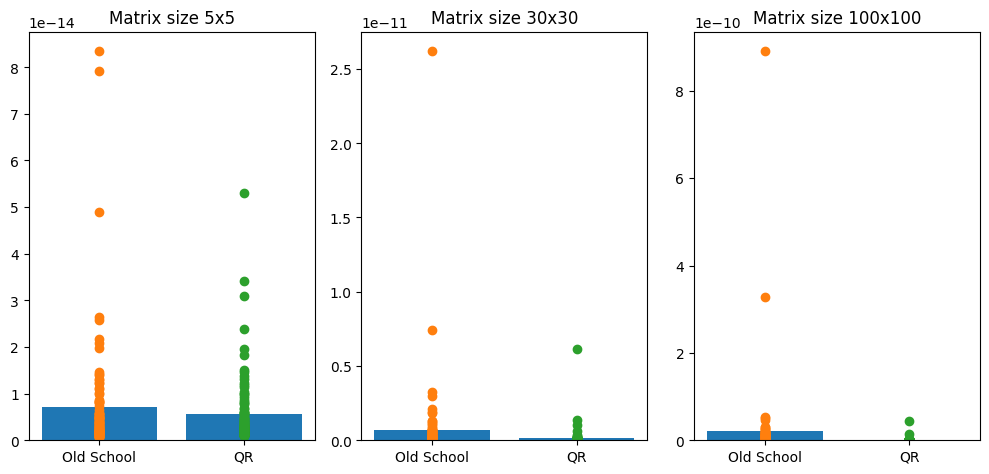

In [125]:
fig, axes = plt.subplots(1, len(matrix_sizes), figsize=(10, 5))
for m_idx, matrix_size in enumerate(matrix_sizes):
    axes[m_idx].set_title(f"Matrix size {matrix_size}x{matrix_size}")
    axes[m_idx].bar(["Old School", "QR"],[results[m_idx*2].mean(), results[m_idx*2+1].mean()])
    axes[m_idx].scatter(x=np.zeros(iterations),y=results[m_idx*2])
    axes[m_idx].scatter(x=1 + np.zeros(iterations),y=results[m_idx*2+1])
plt.tight_layout()

# Exercise 9-6

- All singular values (and the eigen values) of a square orthogonal matrix are 1
- They have an induced 2-norm of 1 (the induced norm is the largest singular value) and they have a Frobenius norm of $M$
- Because the Frobenius norm equals the square root of the sum of the squared singular values
- Create an $M \times M$ orthogonal matrix as the QR decomposition of a random matrix
- Compute it's induced 2-norm using `np.linalg.norm`
- Compute it's Frobenius norm using equation in Ch 6, divided by the square root of $M$
- Confirm that both quantities are 1
- Next explore the meaning of induced norm using matrix-vector multiplication
- Create a random M-element column vector v
- compute the norms of v and Qv
- These norms should equal each other

In [126]:
M_size = 5
Q, _ = np.linalg.qr(np.random.default_rng().random((M_size, M_size)))
Q

array([[-0.28274235,  0.24492809,  0.29002504,  0.84279387, -0.25622443],
       [-0.49665519, -0.63286364, -0.3957551 ,  0.2620546 ,  0.35710294],
       [-0.45267251, -0.07421903, -0.23447314, -0.29433094, -0.80496632],
       [-0.63488136,  0.15090615,  0.58858053, -0.3664641 ,  0.30566325],
       [-0.25574138,  0.71499141, -0.59821291, -0.00996143,  0.25578454]])

In [138]:
# this is one because the largest singular norm in an orthogonal matrix is 1
np.linalg.norm(Q, 2)

np.float64(1.0000000000000002)

In [144]:
# manually find the frobenius norm
frob_norm = 0
for i in range(M_size):
    for j in range(M_size):
        frob_norm += Q[i][j]**2
np.sqrt(frob_norm) / np.sqrt(M_size)

np.float64(1.0)

In [145]:
v = np.random.default_rng().random((M_size, 1))
v

array([[0.22348502],
       [0.37873192],
       [0.08804068],
       [0.96838517],
       [0.03765986]])

In [146]:
np.linalg.norm(v)

np.float64(1.0678589264342295)

In [147]:
# We would expect this norm to equal the norm of 'v' given the Q matrix all has norms of 1
np.linalg.norm(Q @ v)

np.float64(1.0678589264342295)

# Exercise 9-7
- Highlight a feature of $R$ matrix that is relevant for understanding how to use QR to implement least squares
- When $A$ is tall and full column-rank, the first N rows of $R$ are upper-triangular, whereas rows N + 1 through M are zeros
- Confirm by using a random 10x4 matrix
- Do the complete QR decomposition
- $R$ is not invertable because it's nonsquare
- However the submatrix comprising the first N rows is square and full-rank, thus has a full inverse
- and the tall $R$ has a pseuodinverse
- Compute both inveres and confirm that the full inverse of hte first N rows of R equals the first N columns of the pseudoinverse of the tall R

In [149]:
n, m = 10, 4
Q, R = np.linalg.qr(np.random.default_rng().random((n, m)), "complete")
R

array([[-2.03078746, -1.55099141, -1.55904072, -1.11585583],
       [ 0.        ,  1.0117869 , -0.21809354, -0.09889323],
       [ 0.        ,  0.        ,  1.29405749,  0.55736864],
       [ 0.        ,  0.        ,  0.        , -0.83097933],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ]])

In [151]:
R_sub = R[:4,:]
R_sub

array([[-2.03078746, -1.55099141, -1.55904072, -1.11585583],
       [ 0.        ,  1.0117869 , -0.21809354, -0.09889323],
       [ 0.        ,  0.        ,  1.29405749,  0.55736864],
       [ 0.        ,  0.        ,  0.        , -0.83097933]])

In [153]:
R_sub_inv = np.linalg.inv(R_sub)
R_sub_inv

array([[-0.49241982, -0.75484167, -0.72046926,  0.26781807],
       [ 0.        ,  0.98835041,  0.1665713 , -0.0058961 ],
       [ 0.        ,  0.        ,  0.77276319,  0.51832092],
       [-0.        , -0.        , -0.        , -1.20339936]])

In [154]:
R_sub_inv @ R_sub

array([[ 1.00000000e+00, -1.11022302e-16,  1.11022302e-16,
         0.00000000e+00],
       [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         5.55111512e-17],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

In [156]:
R_pinv = np.linalg.pinv(R)
R_pinv

array([[-4.92419823e-01, -7.54841673e-01, -7.20469262e-01,
         2.67818074e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-1.61722520e-16,  9.88350414e-01,  1.66571300e-01,
        -5.89610410e-03,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 3.46792340e-17,  2.00572073e-16,  7.72763192e-01,
         5.18320919e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-1.78099114e-16, -4.70723899e-16, -2.60460217e-16,
        -1.20339936e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00]])

In [164]:
# if we find the distance between the two inverses we see that it's ~0
np.linalg.norm(R_pinv[:,:m] - R_sub_inv)

np.float64(1.9498425367158503e-15)